# HDBSCAN Performance on Agent-Generated Trajectories

Evaluate `st_hdbscan` across realistic synthetic trajectories produced by
the `Agent` simulation (EPR mobility model on the Garden City map). Ground truth comes
directly from `agent.diary`.

**Sweep dimensions**

| Dimension | Values | What it controls |
|---|---|---|
| `seed` | 0–9 | Agent home/workplace and movement |
| `beta_start` | 100, 250, 400 | Burst inter-arrival time → trajectory sparsity |
| `time_thresh` | 20, 60 | HDBSCAN temporal neighborhood (min) |
| `min_pts` | 2, 3 | HDBSCAN core-point threshold |

**Metrics** are time-based (seconds of overlap between detected and ground-truth stop intervals):
- **Precision** — detected stop time that overlaps a true stop / total detected stop time  
- **Recall** — true stop time covered by any detected stop / total true stop time  
- **F1** — harmonic mean

In [1]:
%matplotlib inline
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nomad.city_gen import City
from nomad.traj_gen import Agent
import nomad.stop_detection.hdbscan as HDBSCAN
import nomad.data as data_folder

## 1. Load

Building hub network, gravity matrix, and shortest paths are computed once and reused for all agents.

In [2]:
data_dir = Path(data_folder.__file__).parent
city_path = data_dir / 'garden-city.gpkg'

t0 = time.perf_counter()
city = City.from_geopackage(str(city_path))
city._build_hub_network(hub_size=16)
city.compute_gravity(exponent=2.0)
city.compute_shortest_paths(callable_only=True)

# Pre-sample a pool of home/workplace pairs for the agents
rng_pool = np.random.default_rng(0)
homes      = city.buildings_gdf[city.buildings_gdf['building_type'] == 'home']['id'].to_numpy()
workplaces = city.buildings_gdf[city.buildings_gdf['building_type'] == 'workplace']['id'].to_numpy()
N_AGENTS = 10
home_pool = rng_pool.choice(homes,      size=N_AGENTS, replace=True)
work_pool = rng_pool.choice(workplaces, size=N_AGENTS, replace=True)

TC = {'timestamp': 'timestamp', 'x': 'x', 'y': 'y'}

## 2. Metrics

In [3]:
def _overlap(a_s, a_e, b_s, b_e):
    return max(0, min(a_e, b_e) - max(a_s, b_s))


def temporal_metrics(stops_df, gt, tc):
    """
    Time-based precision / recall / F1.

    Parameters
    ----------
    stops_df : output of st_hdbscan with complete_output=True
    gt       : DataFrame with columns start_ts (int, seconds) and end_ts (int, seconds)
    tc       : traj_cols dict (must include 'timestamp')
    """
    if stops_df is None or stops_df.empty:
        return dict(precision=0.0, recall=0.0, f1=0.0, n_detected=0)

    detected = [
        (int(r[tc['timestamp']]), int(r['end_timestamp']))
        for _, r in stops_df.iterrows()
    ]
    truth = [
        (int(r['start_ts']), int(r['end_ts']))
        for _, r in gt.iterrows()
    ]

    total_det = sum(e - s for s, e in detected)
    total_gt  = sum(e - s for s, e in truth)

    tp = sum(_overlap(ds, de, gs, ge) for ds, de in detected for gs, ge in truth)

    precision = tp / total_det if total_det > 0 else 0.0
    recall    = tp / total_gt  if total_gt  > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )
    return dict(
        precision=round(precision, 4),
        recall=round(recall, 4),
        f1=round(f1, 4),
        n_detected=len(stops_df),
    )


def diary_to_gt(diary):
    """
    Convert agent.diary to a ground-truth stop interval DataFrame.
    Skips transit entries (location is None) and consecutive duplicate
    locations are merged so back-to-back entries at the same building
    count as one stop.
    """
    df = diary[diary['location'].notna()].copy()
    df['end_ts'] = df['timestamp'] + (df['duration'] * 60).astype(int)
    df = df.rename(columns={'timestamp': 'start_ts'})

    # Merge consecutive entries at the same building
    rows = []
    for _, r in df.iterrows():
        if rows and rows[-1]['location'] == r['location'] and r['start_ts'] <= rows[-1]['end_ts']:
            rows[-1]['end_ts'] = r['end_ts']
        else:
            rows.append({'start_ts': r['start_ts'], 'end_ts': r['end_ts'],
                         'location': r['location']})

    gt = pd.DataFrame(rows)
    gt['duration_min'] = (gt['end_ts'] - gt['start_ts']) / 60
    return gt

## 3. Battery Configuration

In [4]:
# Trajectory generation window
START_DT  = pd.Timestamp('2024-01-01T07:00-04:00')
END_DT    = pd.Timestamp('2024-01-02T07:00-04:00')  # 1-day trajectories

# Sampling sparsity: higher beta_start → more time between bursts → sparser
BETA_START_VALS = [100, 250, 400]   # burst inter-arrival time (min)
BETA_PING       = 5                 # ping inter-arrival within burst (min)

# HDBSCAN configurations
HDBSCAN_CONFIGS = [
    dict(time_thresh=20, min_pts=2, min_cluster_size=2, dur_min=5,  label='tt=20 mp=2 mcs=2'),
    dict(time_thresh=60, min_pts=2, min_cluster_size=2, dur_min=5,  label='tt=60 mp=2 mcs=2'),
    dict(time_thresh=60, min_pts=3, min_cluster_size=2, dur_min=5,  label='tt=60 mp=3 mcs=2'),
    dict(time_thresh=60, min_pts=2, min_cluster_size=1, dur_min=5,  label='tt=60 mp=2 mcs=1'),
]

total_runs = N_AGENTS * len(BETA_START_VALS) * len(HDBSCAN_CONFIGS)
print(f'Agents: {N_AGENTS}  |  Sparsity configs: {len(BETA_START_VALS)}  |  HDBSCAN configs: {len(HDBSCAN_CONFIGS)}')
print(f'Total HDBSCAN runs: {total_runs}')

Agents: 10  |  Sparsity configs: 3  |  HDBSCAN configs: 4
Total HDBSCAN runs: 120


## 4. Generate Trajectories

In [5]:
# Generate dense ground-truth trajectories once per agent/seed
agents = {}
for seed in range(N_AGENTS):
    agent = Agent(
        identifier=f'agent_{seed:03d}',
        city=city,
        home=home_pool[seed],
        workplace=work_pool[seed],
        datetime=START_DT,
        seed=seed,
    )
    agent.generate_trajectory(end_time=END_DT, seed=seed)
    agents[seed] = agent

print(f'Generated {len(agents)} dense trajectories')
# Peek at one diary
ex = agents[0]
print(f'\nAgent 0 diary ({len(ex.diary)} entries, {len(ex.trajectory)} ticks):')
ex.diary.head(8)

Generated 10 dense trajectories

Agent 0 diary (17 entries, 1441 ticks):


,datetime,timestamp,duration,location,user_id
0,2024-01-01 07:01:00-04:00,1704106860,60,h-x7-y13,agent_000
1,2024-01-01 08:01:00-04:00,1704110460,4,None,agent_000
2,2024-01-01 08:05:00-04:00,1704110700,41,p-x12-y11,agent_000
3,2024-01-01 08:46:00-04:00,1704113160,5,None,agent_000
4,2024-01-01 08:51:00-04:00,1704113460,190,w-x11-y16,agent_000
5,2024-01-01 12:01:00-04:00,1704124860,8,None,agent_000
6,2024-01-01 12:09:00-04:00,1704125340,37,r-x3-y1,agent_000
7,2024-01-01 12:46:00-04:00,1704127560,6,None,agent_000


## 5. Run

In [6]:
records = []

for seed, agent in agents.items():
    gt = diary_to_gt(agent.diary)

    for beta_start in BETA_START_VALS:
        agent.sample_trajectory(
            beta_ping=BETA_PING,
            beta_start=beta_start,
            beta_durations=beta_start,
            replace_sparse_traj=True,
            seed=seed,
        )
        # Drop datetime column to avoid timestamp/datetime ambiguity in st_hdbscan
        sparse = agent.sparse_traj[['x', 'y', 'timestamp']].copy()
        n_pings = len(sparse)
        q = n_pings / len(agent.trajectory)

        for cfg in HDBSCAN_CONFIGS:
            params = {k: v for k, v in cfg.items() if k != 'label'}

            t0 = time.perf_counter()
            try:
                stops = HDBSCAN.st_hdbscan(
                    sparse.copy(),
                    traj_cols=TC,
                    complete_output=True,
                    **params,
                )
            except Exception as exc:
                print(f'  seed={seed} beta_start={beta_start} {cfg["label"]}: {exc}')
                stops = None
            elapsed = time.perf_counter() - t0

            m = temporal_metrics(stops, gt, TC)
            records.append({
                'seed':         seed,
                'beta_start':   beta_start,
                'q':            round(q, 3),
                'n_pings':      n_pings,
                'n_true_stops': len(gt),
                'hdbscan_cfg':  cfg['label'],
                'runtime_s':    round(elapsed, 4),
                **m,
            })

raw_df = pd.DataFrame(records)
print(f'Done. {len(raw_df)} rows.')
raw_df.head(8)

Done. 120 rows.


,seed,beta_start,q,n_pings,n_true_stops,hdbscan_cfg,runtime_s,precision,recall,f1,n_detected
0,0,100,0.042,60,9,tt=20 mp=2 mcs=2,0.1332,0.9843,0.1546,0.2673,5
1,0,100,0.042,60,9,tt=60 mp=2 mcs=2,0.1283,0.9847,0.1935,0.3234,5
2,0,100,0.042,60,9,tt=60 mp=3 mcs=2,0.1374,0.9847,0.1935,0.3234,5
3,0,100,0.042,60,9,tt=60 mp=2 mcs=1,0.1360,0.9847,0.1935,0.3234,5
4,0,250,0.123,177,9,tt=20 mp=2 mcs=2,0.4364,0.9899,0.6286,0.7689,12
5,0,250,0.123,177,9,tt=60 mp=2 mcs=2,0.4495,0.9902,0.7203,0.8340,8
6,0,250,0.123,177,9,tt=60 mp=3 mcs=2,0.4609,0.9902,0.7203,0.8340,8
7,0,250,0.123,177,9,tt=60 mp=2 mcs=1,0.4474,0.9902,0.7203,0.8340,8


## 6. Summary Tables

### Mean ± std per HDBSCAN config (across agents and sparsities)

In [7]:
summary = (
    raw_df
    .groupby('hdbscan_cfg')[['precision', 'recall', 'f1', 'runtime_s']]
    .agg(['mean', 'std'])
    .round(3)
)
summary.columns = [f'{col}_{stat}' for col, stat in summary.columns]
summary.reset_index()

,hdbscan_cfg,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,runtime_s_mean,runtime_s_std
0,tt=20 mp=2 mcs=2,0.923,0.251,0.388,0.199,0.527,0.221,0.288,0.165
1,tt=60 mp=2 mcs=1,0.923,0.251,0.459,0.223,0.592,0.234,0.277,0.160
2,tt=60 mp=2 mcs=2,0.923,0.251,0.459,0.223,0.592,0.234,0.282,0.162
3,tt=60 mp=3 mcs=2,0.923,0.251,0.458,0.226,0.590,0.235,0.301,0.172


## 7. Visualizations

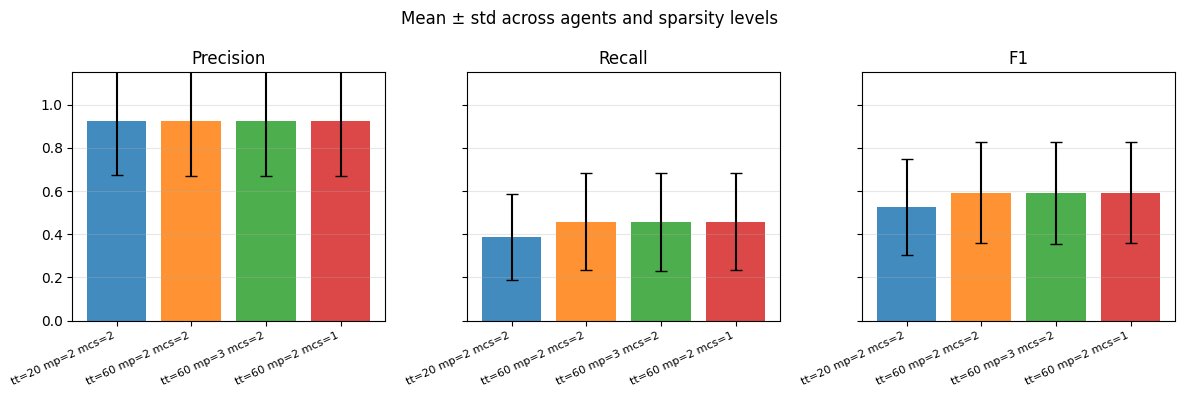

In [9]:
configs = [cfg['label'] for cfg in HDBSCAN_CONFIGS]
palette = dict(zip(configs, sns.color_palette('tab10', n_colors=len(configs))))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, metric in zip(axes, ['precision', 'recall', 'f1']):
    means = raw_df.groupby('hdbscan_cfg')[metric].mean().reindex(configs)
    stds  = raw_df.groupby('hdbscan_cfg')[metric].std().reindex(configs)
    ax.bar(range(len(configs)), means.values, yerr=stds.values,
           color=[palette[c] for c in configs], capsize=4, alpha=0.85)
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(configs, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_title(metric.capitalize())
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Mean ± std across agents and sparsity levels')
plt.tight_layout()
plt.show()